# El Niño and Monsoon Rainfall — India & Sri Lanka (1996–2025)
### Including a current-event (2026) outlook

**Structure:**
1. Setup & imports
2. ONI load, classification, El Niño event detection
3. Region setup (India + Sri Lanka boundaries)
4. Four zones: India Wet/Dry, Sri Lanka Wet/Dry (kept separate by country)
5. CHIRPS precipitation — download, clip, checkpoint save
6. Zone-level ONI–rainfall analysis (JJAS and ONDJ), 4 zones
7. Zones map, precipitation trends, correlation bar chart, country time series
8. NDVI — download, clip, checkpoint save, correlation analysis
9. Regression-based current-event prediction (India only)
10. Current ENSO outlook (live CPC data)
11. Checkpoint reload cell (use after any Colab session reset)


## 0. Setup & Imports

In [ ]:
# Uncomment on a fresh Colab runtime
# !pip install --quiet pooch s3fs boto3 botocore cartopy rioxarray geopandas cftime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 68.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.7.0 which is incompatible.
datasets 4.0.0 require

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from io import StringIO

import xarray as xr
import pooch
import os, tempfile

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd
import rioxarray
from shapely.geometry import box
from shapely.ops import unary_union

from scipy.stats import pearsonr, f_oneway, linregress

sns.set_theme(style="whitegrid")
%matplotlib inline


## 1. Oceanic Niño Index (ONI) — load and classify

NOAA's classic ONI file (`oni.ascii.txt`) is used for the full 1996–2025 historical
analysis. **Note:** as of Feb 2026 NOAA transitioned official ENSO monitoring to a new
index (RONI); the classic ONI file stopped updating around late 2025 as a result. This
does not affect the historical analysis below — it only matters for the current-event
section at the end, which uses live CPC discussion data instead.

In [ ]:
url = "https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt"
resp = requests.get(url, timeout=10)
df = pd.read_csv(StringIO(resp.text), sep=r'\s+')
print(df.tail(3))


    SEAS    YR  TOTAL  ANOM
915  MAM  2026  28.09  0.46
916  AMJ  2026  28.74  0.95
917  MJJ  2026  29.02  1.39


In [ ]:
season_to_month = {
    'DJF': 1, 'JFM': 2, 'FMA': 3, 'MAM': 4, 'AMJ': 5, 'MJJ': 6,
    'JJA': 7, 'JAS': 8, 'ASO': 9, 'SON': 10, 'OND': 11, 'NDJ': 12
}

df['month'] = df['SEAS'].map(season_to_month)
df['date'] = pd.to_datetime(dict(year=df['YR'], month=df['month'], day=1))
df.rename(columns={'ANOM': 'ONI'}, inplace=True)
df['season_label'] = df['SEAS'] + " " + df['YR'].astype(str)

df = df[(df['date'] >= '1996-01-01') & (df['date'] <= '2025-12-31')].reset_index(drop=True)

def classify(oni):
    if oni >= 0.5:
        return "El Nino"
    elif oni <= -0.5:
        return "La Nina"
    else:
        return "Neutral"

df['phase'] = df['ONI'].apply(classify)
df_sorted = df.sort_values('date').reset_index(drop=True)
print(df_sorted.tail(10)[['season_label','ONI','phase']])


    season_label   ONI    phase
350     FMA 2025 -0.08  Neutral
351     MAM 2025  0.02  Neutral
352     AMJ 2025 -0.04  Neutral
353     MJJ 2025 -0.02  Neutral
354     JJA 2025 -0.11  Neutral
355     JAS 2025 -0.26  Neutral
356     ASO 2025 -0.43  Neutral
357     SON 2025 -0.57  La Nina
358     OND 2025 -0.61  La Nina
359     NDJ 2025 -0.60  La Nina


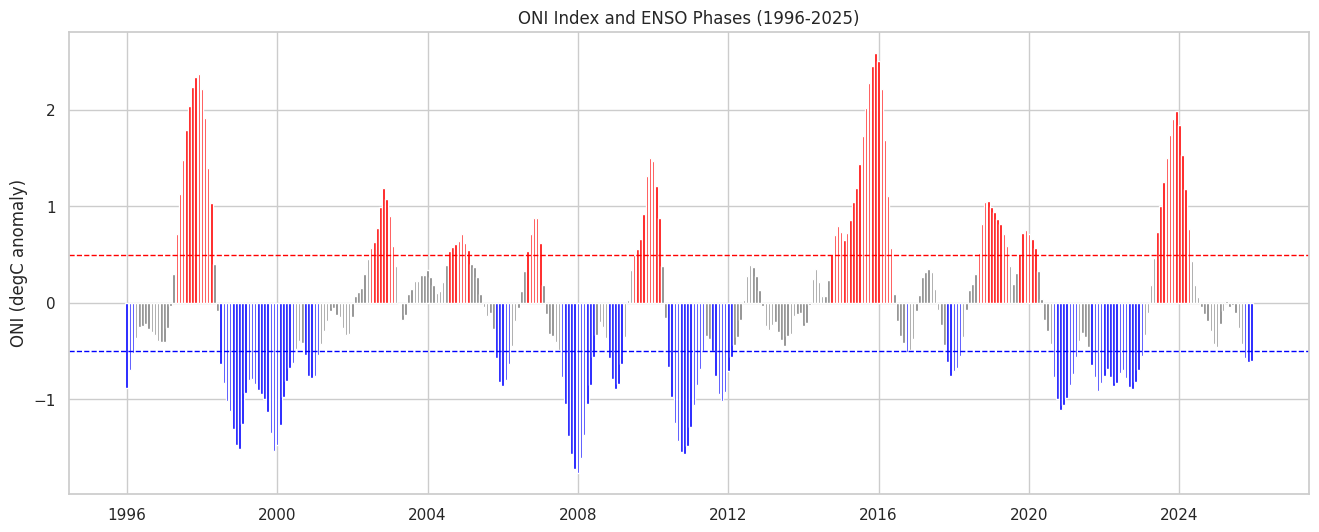

In [ ]:
fig, ax = plt.subplots(figsize=(16,6))
colors = df_sorted['phase'].map({'El Nino':'red','La Nina':'blue','Neutral':'gray'})
ax.bar(df_sorted['date'], df_sorted['ONI'], color=colors, width=25)
ax.axhline(0.5, color='red', ls='--', lw=1)
ax.axhline(-0.5, color='blue', ls='--', lw=1)
ax.set_title("ONI Index and ENSO Phases (1996-2025)")
ax.set_ylabel("ONI (degC anomaly)")

plt.savefig("oni_timeline.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


In [ ]:
from google.colab import files
files.download('oni_timeline.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
is_nino = df_sorted['ONI'] >= 0.5
df_sorted['group'] = (is_nino != is_nino.shift()).cumsum()

nino_events = []
for _, g in df_sorted[is_nino].groupby('group'):
    if len(g) >= 5:
        nino_events.append({
            'start': g['date'].min(),
            'end': g['date'].max(),
            'peak_ONI': g['ONI'].max(),
            'peak_date': g.loc[g['ONI'].idxmax(), 'date']
        })

events_df = pd.DataFrame(nino_events)
events_df['peak_year'] = events_df['peak_date'].dt.year
print(events_df[['start','end','peak_ONI','peak_year']])

nino_years = sorted(set(events_df['peak_year']))
print("El Nino years:", nino_years)


       start        end  peak_ONI  peak_year
0 1997-05-01 1998-04-01      2.37       1997
1 2002-07-01 2003-02-01      1.19       2002
2 2004-08-01 2005-02-01      0.71       2004
3 2006-09-01 2007-01-01      0.88       2006
4 2009-07-01 2010-03-01      1.50       2009
5 2014-10-01 2016-05-01      2.59       2015
6 2018-09-01 2019-06-01      1.05       2018
7 2019-10-01 2020-03-01      0.75       2019
8 2023-06-01 2024-04-01      1.99       2023
El Nino years: [1997, 2002, 2004, 2006, 2009, 2015, 2018, 2019, 2023]


In [ ]:
# Historical strong events (peak ONI >= 2.0) - used later as analogs for the current event
strong_events = events_df[events_df['peak_ONI'] >= 2.0]
print(strong_events[['start','end','peak_ONI','peak_year']])


       start        end  peak_ONI  peak_year
0 1997-05-01 1998-04-01      2.37       1997
5 2014-10-01 2016-05-01      2.59       2015


In [ ]:
event_seasons = []
for idx, row in events_df.iterrows():
    mask = (df_sorted['date'] >= row['start']) & (df_sorted['date'] <= row['end'])
    seasons_in_event = df_sorted.loc[mask, ['season_label','ONI']].reset_index(drop=True)
    event_seasons.append({
        'event_id': idx + 1,
        'peak_year': row['peak_year'],
        'peak_ONI': row['peak_ONI'],
        'seasons': seasons_in_event['season_label'].tolist(),
        'oni_values': seasons_in_event['ONI'].round(2).tolist()
    })

for e in event_seasons:
    print(f"El Nino Event #{e['event_id']} (peak year {e['peak_year']}, peak ONI {e['peak_ONI']:.2f})")


El Nino Event #1 (peak year 1997, peak ONI 2.37)
El Nino Event #2 (peak year 2002, peak ONI 1.19)
El Nino Event #3 (peak year 2004, peak ONI 0.71)
El Nino Event #4 (peak year 2006, peak ONI 0.88)
El Nino Event #5 (peak year 2009, peak ONI 1.50)
El Nino Event #6 (peak year 2015, peak ONI 2.59)
El Nino Event #7 (peak year 2018, peak ONI 1.05)
El Nino Event #8 (peak year 2019, peak ONI 0.75)
El Nino Event #9 (peak year 2023, peak ONI 1.99)


## 2. Region setup — India + Sri Lanka

In [ ]:
url_ne = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url_ne)

region = world[world["ADMIN"].isin(["India", "Sri Lanka"])]
region_bounds = region.total_bounds
region_extent = [region_bounds[0]-1, region_bounds[2]+1, region_bounds[1]-1, region_bounds[3]+1]
print("Map extent [lon_min, lon_max, lat_min, lat_max]:", region_extent)

india_boundary = region[region["ADMIN"]=="India"]
srilanka_boundary = region[region["ADMIN"]=="Sri Lanka"]


Map extent [lon_min, lon_max, lat_min, lat_max]: [np.float64(67.1766451353734), np.float64(98.40256147663614), np.float64(4.968369859232155), np.float64(36.494009507787766)]


## 3. Four zones — kept separate by country

India's Western Ghats (wet) / Deccan (dry) and Sri Lanka's southwest (wet) / north-east
(dry) are clipped to **their own country's boundary independently** — not merged into a
single India+Sri Lanka wet/dry pair. This matters: an earlier, combined-country version
of this analysis showed a much weaker signal, which turned out to be Sri Lanka's data
diluting a real, strong Indian signal (see Section 6).

In [ ]:
india_wet_bbox = gpd.GeoDataFrame(geometry=[box(74, 8, 77.5, 21)], crs="EPSG:4326")
india_dry_bbox = gpd.GeoDataFrame(geometry=[box(76, 15, 80, 21)], crs="EPSG:4326")

srilanka_wet_bbox = gpd.GeoDataFrame(geometry=[box(79.6, 6.0, 80.6, 7.3)], crs="EPSG:4326")
srilanka_dry_bbox = gpd.GeoDataFrame(geometry=[box(80.4, 5.9, 81.9, 9.9)], crs="EPSG:4326")

india_wet_clip = gpd.overlay(india_wet_bbox, india_boundary, how="intersection")
india_dry_clip = gpd.overlay(india_dry_bbox, india_boundary, how="intersection")
srilanka_wet_clip = gpd.overlay(srilanka_wet_bbox, srilanka_boundary, how="intersection")
srilanka_dry_clip = gpd.overlay(srilanka_dry_bbox, srilanka_boundary, how="intersection")


## 4. CHIRPS precipitation — download and clip

In [ ]:
def pooch_load(filelocation=None, filename=None, processor=None):
    user_temp_cache = tempfile.gettempdir()
    file = pooch.retrieve(filelocation, known_hash=None,
                           fname=os.path.join(user_temp_cache, filename),
                           processor=processor)
    return file

years = range(1996, 2026)
file_paths = [f'https://data.chc.ucsb.edu/products/CHIRPS-2.0/global_daily/netcdf/p25/chirps-v2.0.{year}.days_p25.nc' for year in years]
filenames = [f'chirps-v2.0.{year}.days_p25.nc' for year in years]

downloaded_files = [pooch_load(fpath, fname) for fpath, fname in zip(file_paths, filenames)]
chirps_data = xr.open_mfdataset(downloaded_files, combine="by_coords")
chirps_data


SHA256 hash of downloaded file: b0a4604e5a213671e6d591ad959c2156685ee026b54fbc8ad87860e35f3db4df
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
SHA256 hash of downloaded file: a04019a26e20988e35d8d14e88f1083aabb8104434c556c21e3d29e1c30ae731
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
SHA256 hash of downloaded file: 15f3e33707c14b3ef26b525cb116766b847f2295c60aa41c6ae73df10e748e98
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
SHA256 hash of downloaded file: dbb0a6a0ee1ff5e3ba5439101bedc24dad0951810a03a6f5cdc96e4b08c06716
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
SHA256 hash of downloaded file: 5701

<xarray.Dataset> Size: 25GB
Dimensions:    (time: 10958, latitude: 400, longitude: 1440)
Coordinates:
  * time       (time) datetime64[ns] 88kB 1996-01-01 1996-01-02 ... 2025-12-31
  * latitude   (latitude) float32 2kB -49.88 -49.62 -49.38 ... 49.38 49.62 49.88
  * longitude  (longitude) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables:
    precip     (time, latitude, longitude) float32 25GB dask.array<chunksize=(61, 67, 240), meta=np.ndarray>
Attributes: (12/15)
    Conventions:       CF-1.6
    title:             CHIRPS Version 2.0
    history:           created by Climate Hazards Group
    version:           Version 2.0
    date_created:      2015-10-07
    creator_name:      Pete Peterson
    ...                ...
    reference:         Funk, C.C., Peterson, P.J., Landsfeld, M.F., Pedreros,...
    comments:           time variable denotes the first day of the given day.
    acknowledgements:  The Climate Hazards Group InfraRed Precipitation with ...
    ftp_url:           ftp://chg-ftpout.geog.ucsb.edu/pub/org/chg/products/CH...
    website:           http://chg.geog.ucsb.edu/data/chirps/index.html
    faq:               http://chg-wiki.geog.ucsb.edu/wiki/CHIRPS_FAQ

In [ ]:
chirps = (
    chirps_data
    .rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
    .rio.write_crs("EPSG:4326")
)

chirps_region = chirps.rio.clip(region.geometry, region.crs, drop=True)

def zone_mean_precip(chirps_data_, zone_gdf):
    clipped = chirps_data_.rio.clip(zone_gdf.geometry, zone_gdf.crs, drop=True)
    return clipped.precip

india_wet_precip = zone_mean_precip(chirps_region, india_wet_clip)
india_dry_precip = zone_mean_precip(chirps_region, india_dry_clip)
srilanka_wet_precip = zone_mean_precip(chirps_region, srilanka_wet_clip)
srilanka_dry_precip = zone_mean_precip(chirps_region, srilanka_dry_clip)


**Checkpoint A — save zone-averaged monthly rainfall to CSV.**
Run this once after the cell above succeeds, then download the CSV. If your Colab
session resets later, skip straight to Section 11 (Checkpoint Reload) instead of
re-running the CHIRPS download.

In [ ]:
def to_monthly_series(precip_da, colname):
    monthly = precip_da.mean(dim=['latitude','longitude']).resample(time='MS').mean()
    df_ = monthly.to_dataframe(name=colname).reset_index()
    df_.rename(columns={df_.columns[0]: 'date'}, inplace=True)
    return df_[['date', colname]]

precip_checkpoint = to_monthly_series(india_wet_precip, 'india_wet') \
    .merge(to_monthly_series(india_dry_precip, 'india_dry'), on='date') \
    .merge(to_monthly_series(srilanka_wet_precip, 'srilanka_wet'), on='date') \
    .merge(to_monthly_series(srilanka_dry_precip, 'srilanka_dry'), on='date')

precip_checkpoint.to_csv('precip_zone_checkpoint.csv', index=False)
print(precip_checkpoint.shape)

from google.colab import files
files.download('precip_zone_checkpoint.csv')


(360, 5)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 5. Zone-level ONI–rainfall analysis

Tests both **JJAS** (India's southwest monsoon, and Sri Lanka's SW/Yala season) and
**ONDJ** (Sri Lanka's northeast/Maha monsoon, which dominates its dry-zone rainfall).
Testing only JJAS everywhere would unfairly test Sri Lanka's dry zone during its driest
months.

In [ ]:
def zone_analysis(precip_da, label, months):
    monthly = precip_da.mean(dim=['latitude','longitude']).resample(time='MS').mean()
    df_ = monthly.to_dataframe(name='val').reset_index()
    df_.rename(columns={df_.columns[0]:'date'}, inplace=True)
    df_['month'] = df_['date'].dt.month
    df_['clim'] = df_.groupby('month')['val'].transform('mean')
    df_['anom'] = df_['val'] - df_['clim']
    merged = pd.merge(df_[['date','anom']], df_sorted[['date','ONI','phase']], on='date', how='inner')

    r_all, p_all = pearsonr(merged['ONI'], merged['anom'])

    seas = merged[merged['date'].dt.month.isin(months)]
    r_seas, p_seas = pearsonr(seas['ONI'], seas['anom'])

    el_nino = seas[seas['phase']=='El Nino']['anom']
    la_nina = seas[seas['phase']=='La Nina']['anom']
    neutral = seas[seas['phase']=='Neutral']['anom']
    f_stat, p_anova = f_oneway(el_nino, la_nina, neutral)

    print(f"--- {label} ---")
    print(f"All months: r={r_all:.3f}, p={p_all:.4f}")
    print(f"Season only: r={r_seas:.3f}, p={p_seas:.4f}")
    print(f"ANOVA: F={f_stat:.3f}, p={p_anova:.4f}")
    print(f"Mean seasonal anomaly — El Nino: {el_nino.mean():.2f}, La Nina: {la_nina.mean():.2f}, Neutral: {neutral.mean():.2f}\n")

    return {'zone': label, 'r_all': r_all, 'p_all': p_all, 'r_seas': r_seas, 'p_seas': p_seas,
            'F': f_stat, 'p_anova': p_anova, 'el_nino_mean': el_nino.mean(),
            'la_nina_mean': la_nina.mean(), 'neutral_mean': neutral.mean(), 'merged': merged}

def sig_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return ""


In [ ]:
JJAS = [6,7,8,9]

jjas_results = []
jjas_results.append(zone_analysis(india_wet_precip, "India Wet (Western Ghats)", JJAS))
jjas_results.append(zone_analysis(india_dry_precip, "India Dry (Deccan)", JJAS))
jjas_results.append(zone_analysis(srilanka_wet_precip, "Sri Lanka Wet (SW)", JJAS))
jjas_results.append(zone_analysis(srilanka_dry_precip, "Sri Lanka Dry (N/E)", JJAS))

results_jjas_df = pd.DataFrame(jjas_results).drop(columns='merged')
print(results_jjas_df)


--- India Wet (Western Ghats) ---
All months: r=-0.196, p=0.0002
Season only: r=-0.399, p=0.0000
ANOVA: F=9.207, p=0.0002
Mean seasonal anomaly — El Nino: -1.18, La Nina: 0.93, Neutral: 0.08

--- India Dry (Deccan) ---
All months: r=-0.208, p=0.0001
Season only: r=-0.391, p=0.0000
ANOVA: F=11.229, p=0.0000
Mean seasonal anomaly — El Nino: -1.39, La Nina: 1.13, Neutral: 0.08

--- Sri Lanka Wet (SW) ---
All months: r=0.071, p=0.1806
Season only: r=0.102, p=0.2698
ANOVA: F=0.773, p=0.4640
Mean seasonal anomaly — El Nino: 0.74, La Nina: 0.24, Neutral: -0.31

--- Sri Lanka Dry (N/E) ---
All months: r=-0.017, p=0.7447
Season only: r=-0.102, p=0.2692
ANOVA: F=1.343, p=0.2652
Mean seasonal anomaly — El Nino: -0.06, La Nina: 0.39, Neutral: -0.10

                        zone     r_all     p_all    r_seas    p_seas  \
0  India Wet (Western Ghats) -0.195972  0.000183 -0.399488  0.000006   
1         India Dry (Deccan) -0.207757  0.000071 -0.390651  0.000010   
2         Sri Lanka Wet (SW)  0.0707

In [ ]:
ONDJ = [10,11,12,1]

ondj_results = []
ondj_results.append(zone_analysis(india_wet_precip, "India Wet (Western Ghats)", ONDJ))
ondj_results.append(zone_analysis(india_dry_precip, "India Dry (Deccan)", ONDJ))
ondj_results.append(zone_analysis(srilanka_wet_precip, "Sri Lanka Wet (SW)", ONDJ))
ondj_results.append(zone_analysis(srilanka_dry_precip, "Sri Lanka Dry (N/E)", ONDJ))

results_ondj_df = pd.DataFrame(ondj_results).drop(columns='merged')
print(results_ondj_df)


--- India Wet (Western Ghats) ---
All months: r=-0.196, p=0.0002
Season only: r=-0.081, p=0.3787
ANOVA: F=0.212, p=0.8093
Mean seasonal anomaly — El Nino: -0.05, La Nina: 0.06, Neutral: -0.05

--- India Dry (Deccan) ---
All months: r=-0.208, p=0.0001
Season only: r=-0.148, p=0.1073
ANOVA: F=1.872, p=0.1584
Mean seasonal anomaly — El Nino: -0.18, La Nina: 0.05, Neutral: 0.15

--- Sri Lanka Wet (SW) ---
All months: r=0.071, p=0.1806
Season only: r=0.269, p=0.0030
ANOVA: F=7.320, p=0.0010
Mean seasonal anomaly — El Nino: 1.74, La Nina: -0.57, Neutral: -1.37

--- Sri Lanka Dry (N/E) ---
All months: r=-0.017, p=0.7447
Season only: r=0.095, p=0.3010
ANOVA: F=2.607, p=0.0780
Mean seasonal anomaly — El Nino: 1.01, La Nina: -0.19, Neutral: -1.04

                        zone     r_all     p_all    r_seas    p_seas  \
0  India Wet (Western Ghats) -0.195972  0.000183 -0.081072  0.378720   
1         India Dry (Deccan) -0.207757  0.000071 -0.147762  0.107276   
2         Sri Lanka Wet (SW)  0.0707

## 6. Maps and figures

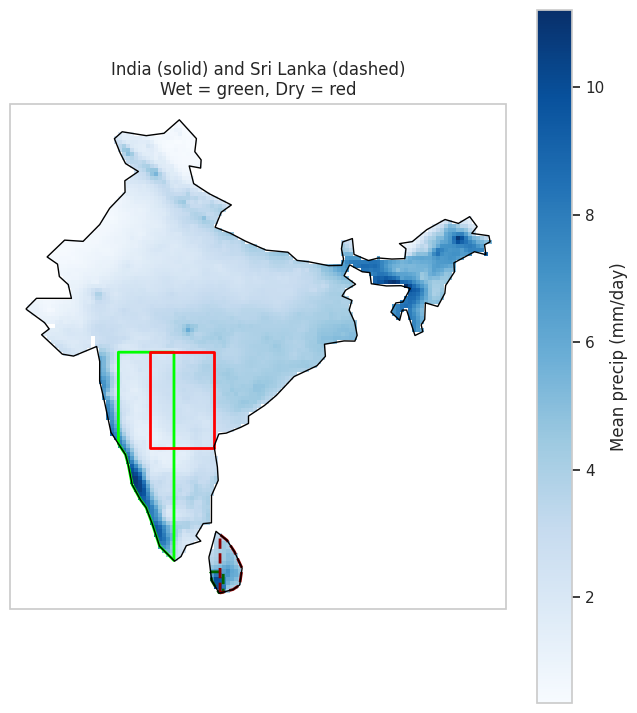

In [ ]:
fig, ax = plt.subplots(figsize=(8,9), subplot_kw={"projection": ccrs.PlateCarree()})
chirps_region.precip.mean("time").plot(ax=ax, transform=ccrs.PlateCarree(), cmap="Blues", cbar_kwargs={"label":"Mean precip (mm/day)"})
region.boundary.plot(ax=ax, edgecolor="black", linewidth=1, transform=ccrs.PlateCarree())
india_wet_clip.plot(ax=ax, facecolor="none", edgecolor="lime", linewidth=2, transform=ccrs.PlateCarree())
india_dry_clip.plot(ax=ax, facecolor="none", edgecolor="red", linewidth=2, transform=ccrs.PlateCarree())
srilanka_wet_clip.plot(ax=ax, facecolor="none", edgecolor="darkgreen", linewidth=2, linestyle='--', transform=ccrs.PlateCarree())
srilanka_dry_clip.plot(ax=ax, facecolor="none", edgecolor="darkred", linewidth=2, linestyle='--', transform=ccrs.PlateCarree())
ax.set_extent(region_extent, crs=ccrs.PlateCarree())
ax.set_title("India (solid) and Sri Lanka (dashed)\nWet = green, Dry = red")

plt.savefig("zones_map.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


In [ ]:
from google.colab import files
files.download('zones_map.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_2689/1674502249.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(yrs, vals, 'o-', color=color, linestyle=style, markersize=4, label=f'{label} (slope={slope:+.3f})')
/tmp/ipykernel_2689/1674502249.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(yrs, vals, 'o-', color=color, linestyle=style, markersize=4, label=f'{label} (slope={slope:+.3f})')
/tmp/ipykernel_2689/1674502249.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(yrs, vals, 'o-', color=color, linestyle=style, markersize=4, label=f'{label} (slope={slope:+.3f})')
/tmp/ipykernel_2689/1674502249.py:22: UserWarning

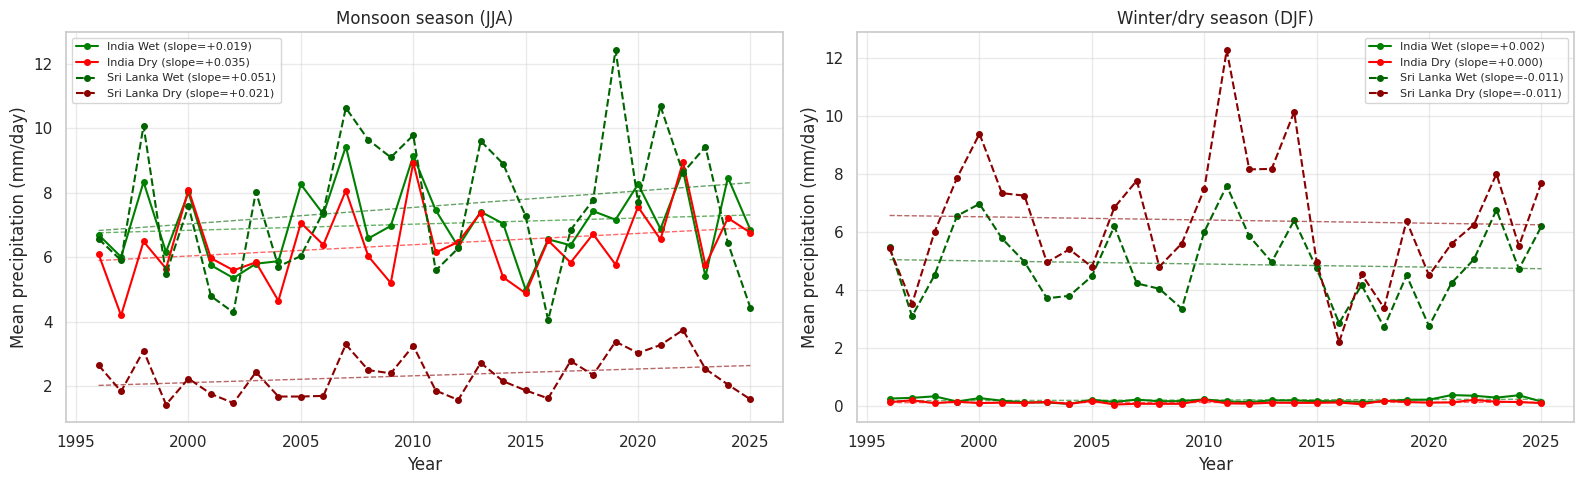

In [ ]:
def seasonal_trend(data, season):
    seasonal = data.where(data['time.season']==season)
    mean_ts = seasonal.mean(dim=['latitude','longitude'])
    annual = mean_ts.groupby('time.year').mean('time')
    years = annual.year.values
    vals = annual.values
    coef = np.polyfit(years, vals, 1)
    trend = np.polyval(coef, years)
    return years, vals, trend, coef[0]

fig, axes = plt.subplots(1, 2, figsize=(16,5))
zone_list = [
    (india_wet_precip, 'India Wet', 'green', '-'),
    (india_dry_precip, 'India Dry', 'red', '-'),
    (srilanka_wet_precip, 'Sri Lanka Wet', 'darkgreen', '--'),
    (srilanka_dry_precip, 'Sri Lanka Dry', 'darkred', '--'),
]

for season, ax, title in zip(['JJA','DJF'], axes, ['Monsoon season (JJA)', 'Winter/dry season (DJF)']):
    for precip_da, label, color, style in zone_list:
        yrs, vals, trend, slope = seasonal_trend(precip_da, season)
        ax.plot(yrs, vals, 'o-', color=color, linestyle=style, markersize=4, label=f'{label} (slope={slope:+.3f})')
        ax.plot(yrs, trend, '--', color=color, linewidth=1, alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("Year"); ax.set_ylabel("Mean precipitation (mm/day)")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("precip_trends.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


In [ ]:
from google.colab import files
files.download('precip_trends.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

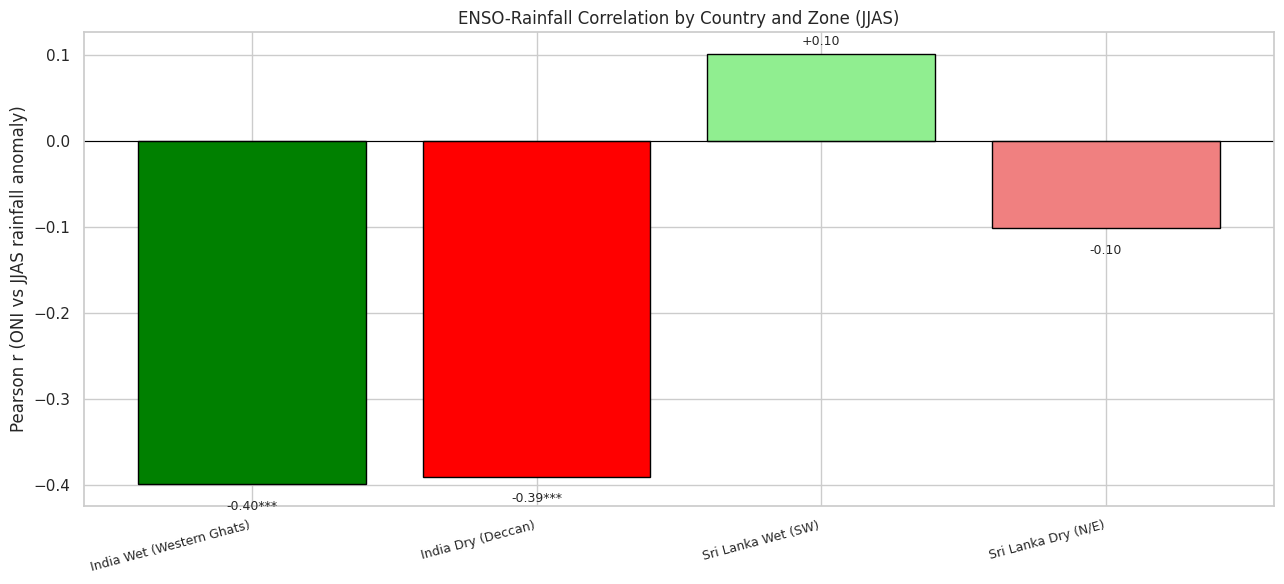

Significance: * p<0.05  ** p<0.01  *** p<0.001


In [ ]:
fig, ax = plt.subplots(figsize=(13,6))
zones = results_jjas_df['zone'].tolist()
vals = results_jjas_df['r_seas'].tolist()
pvals = results_jjas_df['p_seas'].tolist()
colors = ['green','red','lightgreen','lightcoral']

bars = ax.bar(zones, vals, color=colors, edgecolor='black')
for bar, r, p in zip(bars, vals, pvals):
    stars = sig_stars(p)
    y_offset = 0.01 if r >= 0 else -0.03
    ax.text(bar.get_x()+bar.get_width()/2, r + y_offset, f"{r:+.2f}{stars}", ha='center', fontsize=9)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(len(zones)))
ax.set_xticklabels(zones, rotation=15, ha='right', fontsize=9)
ax.set_ylabel("Pearson r (ONI vs JJAS rainfall anomaly)")
ax.set_title("ENSO-Rainfall Correlation by Country and Zone (JJAS)")
plt.tight_layout()

plt.savefig("four_zone_correlation.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Significance: * p<0.05  ** p<0.01  *** p<0.001")


In [ ]:
from google.colab import files
files.download('four_zone_correlation.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

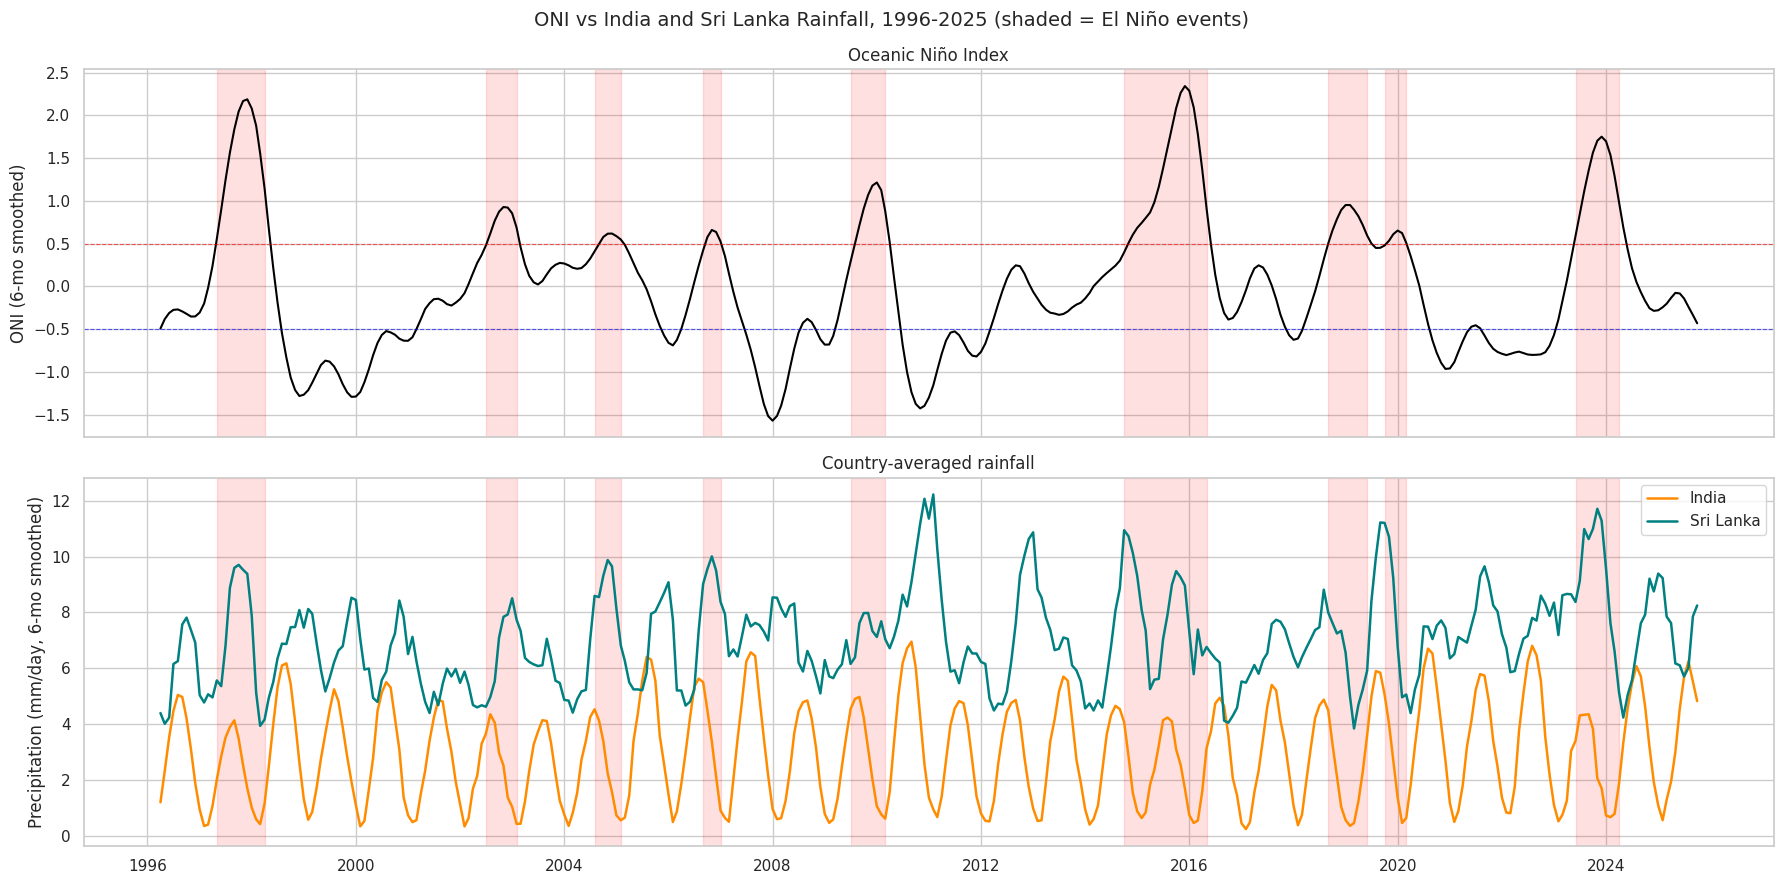

In [ ]:
india_avg = ((india_wet_precip.mean(dim=['latitude','longitude']) + india_dry_precip.mean(dim=['latitude','longitude'])) / 2).resample(time='MS').mean()
srilanka_avg = ((srilanka_wet_precip.mean(dim=['latitude','longitude']) + srilanka_dry_precip.mean(dim=['latitude','longitude'])) / 2).resample(time='MS').mean()

india_df = india_avg.to_dataframe(name='india_precip').reset_index().rename(columns={'time':'date'})
srilanka_df = srilanka_avg.to_dataframe(name='srilanka_precip').reset_index().rename(columns={'time':'date'})

compare_ts = df_sorted[['date','ONI']].merge(india_df, on='date').merge(srilanka_df, on='date')
SMOOTH_WINDOW = 6
compare_ts['india_smooth'] = compare_ts['india_precip'].rolling(SMOOTH_WINDOW, center=True).mean()
compare_ts['srilanka_smooth'] = compare_ts['srilanka_precip'].rolling(SMOOTH_WINDOW, center=True).mean()
compare_ts['ONI_smooth'] = compare_ts['ONI'].rolling(SMOOTH_WINDOW, center=True).mean()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18,9), sharex=True)
for _, row in events_df.iterrows():
    ax1.axvspan(row['start'], row['end'], color='red', alpha=0.12)
    ax2.axvspan(row['start'], row['end'], color='red', alpha=0.12)

ax1.plot(compare_ts['date'], compare_ts['ONI_smooth'], color='black', linewidth=1.5)
ax1.axhline(0.5, color='red', ls='--', lw=0.8, alpha=0.6)
ax1.axhline(-0.5, color='blue', ls='--', lw=0.8, alpha=0.6)
ax1.set_ylabel('ONI (6-mo smoothed)')
ax1.set_title('Oceanic Niño Index')

ax2.plot(compare_ts['date'], compare_ts['india_smooth'], color='darkorange', linewidth=1.8, label='India')
ax2.plot(compare_ts['date'], compare_ts['srilanka_smooth'], color='teal', linewidth=1.8, label='Sri Lanka')
ax2.set_ylabel('Precipitation (mm/day, 6-mo smoothed)')
ax2.set_title('Country-averaged rainfall')
ax2.legend(loc='upper right')

fig.suptitle("ONI vs India and Sri Lanka Rainfall, 1996-2025 (shaded = El Niño events)", fontsize=14)
plt.tight_layout()

fig.savefig("india_srilanka_timeseries.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


In [ ]:
from google.colab import files
files.download('india_srilanka_timeseries.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. NDVI — download, clip, checkpoint save

In [ ]:
import s3fs, boto3, botocore, datetime

fs = s3fs.S3FileSystem(anon=True)

def get_ndvi_file_for_month(year, month):
    date_sel = datetime.datetime(year, month, 15)
    pattern = (f's3://noaa-cdr-ndvi-pds/data/{date_sel.strftime("%Y")}/'
               f'AVHRR-Land_v005_AVH13C1_*{date_sel.strftime("%Y%m")}*_c*.nc')
    matches = fs.glob(pattern)
    return matches[0] if matches else None

ndvi_files = []
for year in range(1996, 2026):
    for month in range(1, 13):
        f = get_ndvi_file_for_month(year, month)
        if f:
            ndvi_files.append(f)
print(f"Found {len(ndvi_files)} monthly NDVI files")


Found 216 monthly NDVI files


In [ ]:
ndvi_local = [pooch_load('http://s3.amazonaws.com/'+f, f.split('/')[-1]) for f in ndvi_files]
ndvi_ds = xr.open_mfdataset(ndvi_local, combine="by_coords", decode_times=False)

def get_quality_info_AVHRR(QA):
    cld_flag = (QA % (2**2)) // 2
    cld_shadow = (QA % (2**3)) // 2**2
    value_valid = (QA % (2**8)) // 2**7
    return (cld_flag == 0) & (cld_shadow == 0) & (value_valid == 1)

mask = get_quality_info_AVHRR(ndvi_ds.QA)
ndvi_masked = ndvi_ds.NDVI.where(mask)
ndvi_masked['time'] = pd.date_range('1996-01-01', periods=len(ndvi_local), freq='MS')
ndvi_masked = ndvi_masked.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude")
ndvi_masked = ndvi_masked.rio.write_crs("EPSG:4326")


SHA256 hash of downloaded file: b622bb9f56ffebbd4cd545175d8b3063c6394f551e6c0c00b18b9c95b1503a72
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
SHA256 hash of downloaded file: a945ef0b356cdb718d8adf6ab1fa205c60ba03c268fcffd86105308bbe0e0a24
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
SHA256 hash of downloaded file: 8f3ee7a8c683c7b427909d1c99e3dbb6a478d4f09fb3c8f36612af7b6da57b77
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
SHA256 hash of downloaded file: 83c0b5bf7e695f3a32d194c76124b65f509b4f17a6839bc7f7fb76ae4ba0922b
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.
SHA256 hash of downloaded file: 0366

In [ ]:
def zone_mean_ndvi(ndvi_data, zone_gdf):
    clipped = ndvi_data.rio.clip(zone_gdf.geometry, zone_gdf.crs, drop=True)
    return clipped.mean(dim=['latitude','longitude'])

ndvi_india_wet = zone_mean_ndvi(ndvi_masked, india_wet_clip)
ndvi_india_dry = zone_mean_ndvi(ndvi_masked, india_dry_clip)
ndvi_srilanka_wet = zone_mean_ndvi(ndvi_masked, srilanka_wet_clip)
ndvi_srilanka_dry = zone_mean_ndvi(ndvi_masked, srilanka_dry_clip)


**Checkpoint B — save zone-averaged monthly NDVI to CSV, then download.**

In [ ]:
def ndvi_to_monthly_series(ndvi_da, colname):
    df_ = ndvi_da.to_dataframe(name=colname).reset_index()
    df_.rename(columns={df_.columns[0]: 'date'}, inplace=True)
    return df_[['date', colname]]

ndvi_checkpoint = ndvi_to_monthly_series(ndvi_india_wet, 'india_wet') \
    .merge(ndvi_to_monthly_series(ndvi_india_dry, 'india_dry'), on='date') \
    .merge(ndvi_to_monthly_series(ndvi_srilanka_wet, 'srilanka_wet'), on='date') \
    .merge(ndvi_to_monthly_series(ndvi_srilanka_dry, 'srilanka_dry'), on='date')

ndvi_checkpoint.to_csv('ndvi_zone_checkpoint.csv', index=False)
print(ndvi_checkpoint.shape)

from google.colab import files
files.download('ndvi_zone_checkpoint.csv')


(216, 5)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def to_anomaly(da_or_series, is_dataarray=True):
    if is_dataarray:
        df_ = da_or_series.to_dataframe(name='val').reset_index()
        df_.rename(columns={df_.columns[0]:'date'}, inplace=True)
    else:
        df_ = da_or_series.copy()
    clim = df_.groupby(df_['date'].dt.month)['val'].transform('mean')
    df_['anom'] = df_['val'] - clim
    return df_[['date','anom']]

def build_zone_df(rain_anom, ndvi_anom, lag=1):
    merged = pd.merge(rain_anom, ndvi_anom, on='date', suffixes=('_rain','_ndvi'))
    merged['rain_anom_lagged'] = merged['anom_rain'].shift(lag)
    merged = pd.merge(merged, df_sorted[['date','phase']], on='date', how='inner')
    return merged.dropna(subset=['rain_anom_lagged','anom_ndvi'])

rain_india_wet_monthly = india_wet_precip.mean(dim=['latitude','longitude']).resample(time='MS').mean()
rain_india_dry_monthly = india_dry_precip.mean(dim=['latitude','longitude']).resample(time='MS').mean()
rain_srilanka_wet_monthly = srilanka_wet_precip.mean(dim=['latitude','longitude']).resample(time='MS').mean()
rain_srilanka_dry_monthly = srilanka_dry_precip.mean(dim=['latitude','longitude']).resample(time='MS').mean()

rain_india_wet_anom = to_anomaly(rain_india_wet_monthly)
rain_india_dry_anom = to_anomaly(rain_india_dry_monthly)
rain_srilanka_wet_anom = to_anomaly(rain_srilanka_wet_monthly)
rain_srilanka_dry_anom = to_anomaly(rain_srilanka_dry_monthly)

ndvi_india_wet_anom = to_anomaly(ndvi_india_wet)
ndvi_india_dry_anom = to_anomaly(ndvi_india_dry)
ndvi_srilanka_wet_anom = to_anomaly(ndvi_srilanka_wet)
ndvi_srilanka_dry_anom = to_anomaly(ndvi_srilanka_dry)

india_wet_merged = build_zone_df(rain_india_wet_anom, ndvi_india_wet_anom)
india_dry_merged = build_zone_df(rain_india_dry_anom, ndvi_india_dry_anom)
srilanka_wet_merged = build_zone_df(rain_srilanka_wet_anom, ndvi_srilanka_wet_anom)
srilanka_dry_merged = build_zone_df(rain_srilanka_dry_anom, ndvi_srilanka_dry_anom)

results = []
for zone_name, merged in [
    ('India Dry (Deccan)', india_dry_merged),
    ('India Wet (Western Ghats)', india_wet_merged),
    ('Sri Lanka Dry (N/E)', srilanka_dry_merged),
    ('Sri Lanka Wet (SW)', srilanka_wet_merged),
]:
    for phase in ['El Nino', 'La Nina', 'Neutral']:
        sub = merged[merged['phase'] == phase]
        if len(sub) >= 5:
            r, p = pearsonr(sub['rain_anom_lagged'], sub['anom_ndvi'])
            results.append({'zone': zone_name, 'phase': phase, 'r': r, 'p': p, 'stars': sig_stars(p)})

results_ndvi_df = pd.DataFrame(results)
print(results_ndvi_df)


                         zone    phase         r         p stars
0          India Dry (Deccan)  El Nino -0.084826  0.602776      
1          India Dry (Deccan)  La Nina  0.146247  0.237635      
2          India Dry (Deccan)  Neutral  0.004202  0.968468      
3   India Wet (Western Ghats)  El Nino  0.122190  0.446620      
4   India Wet (Western Ghats)  La Nina  0.154740  0.207681      
5   India Wet (Western Ghats)  Neutral  0.022505  0.827711      
6         Sri Lanka Dry (N/E)  El Nino  0.039014  0.826601      
7         Sri Lanka Dry (N/E)  La Nina -0.274925  0.048551     *
8         Sri Lanka Dry (N/E)  Neutral -0.102732  0.349481      
9          Sri Lanka Wet (SW)  El Nino -0.309073  0.262325      
10         Sri Lanka Wet (SW)  La Nina -0.319343  0.097628      
11         Sri Lanka Wet (SW)  Neutral -0.075568  0.617681      


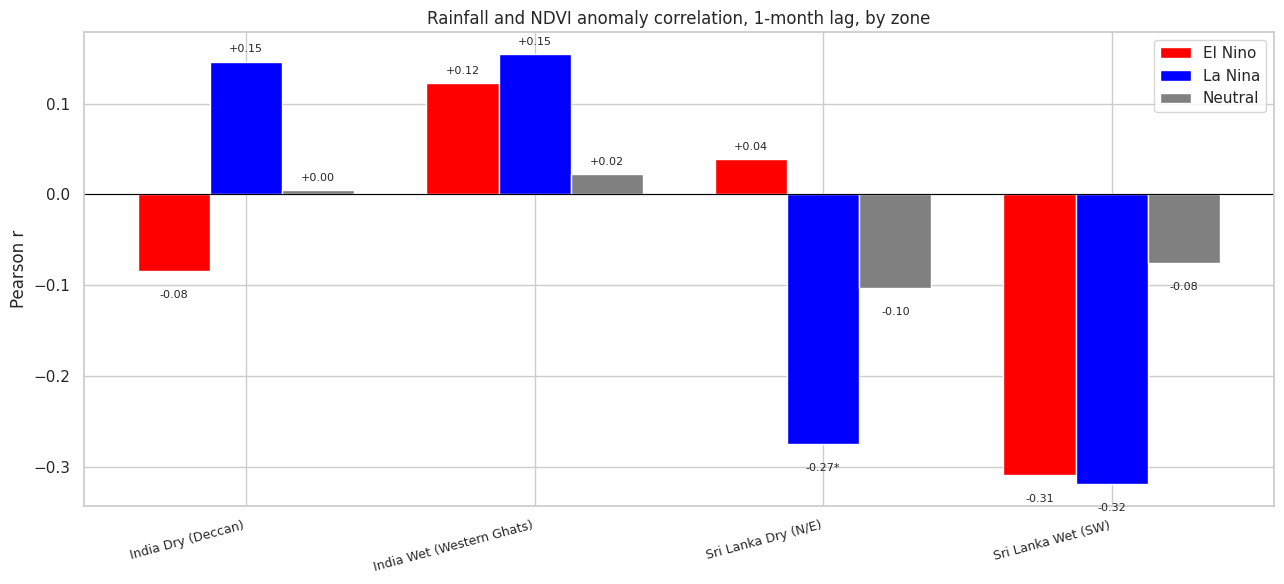

Significance: * p<0.05  ** p<0.01  *** p<0.001  (no symbol = not significant)


In [ ]:
fig, ax = plt.subplots(figsize=(13,6))
zones = results_ndvi_df['zone'].unique()
phases = ['El Nino', 'La Nina', 'Neutral']
colors = {'El Nino':'red', 'La Nina':'blue', 'Neutral':'gray'}
width = 0.25
x = np.arange(len(zones))

for i, phase in enumerate(phases):
    vals = [results_ndvi_df[(results_ndvi_df['zone']==z) & (results_ndvi_df['phase']==phase)]['r'].values[0]
            if len(results_ndvi_df[(results_ndvi_df['zone']==z) & (results_ndvi_df['phase']==phase)]) else 0
            for z in zones]
    stars = [results_ndvi_df[(results_ndvi_df['zone']==z) & (results_ndvi_df['phase']==phase)]['stars'].values[0]
             if len(results_ndvi_df[(results_ndvi_df['zone']==z) & (results_ndvi_df['phase']==phase)]) else ""
             for z in zones]
    bars = ax.bar(x + i*width, vals, width, label=phase, color=colors[phase])
    for bar, star, val in zip(bars, stars, vals):
        y_offset = 0.01 if val >= 0 else -0.03
        ax.text(bar.get_x()+bar.get_width()/2, val + y_offset, f"{val:+.2f}{star}", ha='center', fontsize=8)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(zones, rotation=15, ha='right', fontsize=9)
ax.set_ylabel("Pearson r")
ax.set_title("Rainfall and NDVI anomaly correlation, 1-month lag, by zone")
ax.legend()
plt.tight_layout()

plt.savefig("ndvi_correlation.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Significance: * p<0.05  ** p<0.01  *** p<0.001  (no symbol = not significant)")


## 8. Regression-based prediction for the current (2026) El Niño event

**India only.** Sri Lanka showed no statistically significant ONI–rainfall
relationship in Section 5, so a regression-based prediction for Sri Lanka would not be
statistically defensible — it is intentionally omitted here.

In [ ]:
india_wet_jjas_reg = pd.merge(rain_india_wet_anom, df_sorted[['date','ONI']], on='date')
india_wet_jjas_reg = india_wet_jjas_reg[india_wet_jjas_reg['date'].dt.month.isin([6,7,8,9])]
slope_wet, intercept_wet, r_wet, p_wet, se_wet = linregress(india_wet_jjas_reg['ONI'], india_wet_jjas_reg['anom'])
print(f"India Wet regression: slope={slope_wet:.3f}, intercept={intercept_wet:.3f}, r={r_wet:.3f}, p={p_wet:.4f}")

india_dry_jjas_reg = pd.merge(rain_india_dry_anom, df_sorted[['date','ONI']], on='date')
india_dry_jjas_reg = india_dry_jjas_reg[india_dry_jjas_reg['date'].dt.month.isin([6,7,8,9])]
slope_dry, intercept_dry, r_dry, p_dry, se_dry = linregress(india_dry_jjas_reg['ONI'], india_dry_jjas_reg['anom'])
print(f"India Dry regression: slope={slope_dry:.3f}, intercept={intercept_dry:.3f}, r={r_dry:.3f}, p={p_dry:.4f}")


India Wet regression: slope=-1.078, intercept=-0.004, r=-0.399, p=0.0000
India Dry regression: slope=-1.149, intercept=-0.005, r=-0.391, p=0.0000


In [ ]:
# Current confirmed Nino 3.4 value per CPC ENSO Diagnostic Discussion (Jul 2026): +1.2 C, El Nino Advisory, still strengthening
current_oni_estimate = 1.2

predicted_india_wet_current = slope_wet * current_oni_estimate + intercept_wet
predicted_india_dry_current = slope_dry * current_oni_estimate + intercept_dry
print(f"Predicted India Wet zone JJAS anomaly at ONI=+1.2: {predicted_india_wet_current:+.2f} mm/day")
print(f"Predicted India Dry zone JJAS anomaly at ONI=+1.2: {predicted_india_dry_current:+.2f} mm/day")

print("\nScenario table (if the event continues strengthening toward 'very strong'):")
for scenario_oni in [1.2, 1.8, 2.4]:
    pred_wet = slope_wet * scenario_oni + intercept_wet
    pred_dry = slope_dry * scenario_oni + intercept_dry
    print(f"At ONI={scenario_oni}: Wet zone {pred_wet:+.2f} mm/day, Dry zone {pred_dry:+.2f} mm/day")


Predicted India Wet zone JJAS anomaly at ONI=+1.2: -1.30 mm/day
Predicted India Dry zone JJAS anomaly at ONI=+1.2: -1.38 mm/day

Scenario table (if the event continues strengthening toward 'very strong'):
At ONI=1.2: Wet zone -1.30 mm/day, Dry zone -1.38 mm/day
At ONI=1.8: Wet zone -1.94 mm/day, Dry zone -2.07 mm/day
At ONI=2.4: Wet zone -2.59 mm/day, Dry zone -2.76 mm/day


## 9. Current ENSO outlook (live data, not part of the 1996–2025 historical record)

Fetches the live CPC ENSO Diagnostic Discussion for the current synopsis. As of the
July 2026 discussion: **El Niño Advisory**, Niño 3.4 index +1.2°C and strengthening,
97% chance of persisting through early spring 2027.

In [ ]:
import re

resp = requests.get("https://www.cpc.ncep.noaa.gov/products/analysis_monitoring/enso_advisory/ensodisc.shtml")
clean_text = re.sub('<[^<]+?>', '', resp.text)
clean_text = re.sub(r'\n\s*\n', '\n', clean_text)

idx = clean_text.find("Synopsis")
print(clean_text[idx:idx+800])


Synopsis:&nbsp;
El Ni&ntilde;o is strengthening, with a greater than 90&#37; chance of a very strong event during the Northern Hemisphere fall and winter 2026-27.
									El Ni&ntilde;o strengthened over the past month, with sea surface temperature anomalies exceeding +2.0&deg;C in the eastern equatorial Pacific [Fig. 1]. The July Ni&ntilde;o index values were +1.4&deg;C in Ni&ntilde;o-3.4, +1.7&deg;C in Ni&ntilde;o-3, and +2.9&deg;C in Ni&ntilde;o-1+2 [Fig. 2]. The equatorial subsurface temperature index (average from 180&deg;-100&deg;W) increased during July [Fig. 3], reflecting a deeper-than-average thermocline [Fig. 4]. Subsurface temperature anomalies were significant, reaching +10.0&deg;C at depth. Low-level westerly wind anomalies and upper-level easterly wind anomalies extended fr


In [ ]:
# Historical analogs: past El Nino events of comparable/greater peak strength
print("Historical strong-event analogs (peak ONI >= 2.0):")
print(strong_events[['start','end','peak_ONI','peak_year']])

print("\nJJAS rainfall during these analog years, India Wet zone:")
analog_years = strong_events['peak_year'].tolist()
india_wet_jjas_all = india_wet_jjas_reg.copy()
analog_rain = india_wet_jjas_all[india_wet_jjas_all['date'].dt.year.isin(analog_years)]
print(analog_rain[['date','anom']])
print(f"Mean: {analog_rain['anom'].mean():+.2f} mm/day (vs regression prediction of {predicted_india_wet_current:+.2f} mm/day at current ONI)")


Historical strong-event analogs (peak ONI >= 2.0):
       start        end  peak_ONI  peak_year
0 1997-05-01 1998-04-01      2.37       1997
5 2014-10-01 2016-05-01      2.59       2015

JJAS rainfall during these analog years, India Wet zone:
          date      anom
17  1997-06-01 -0.449105
18  1997-07-01 -1.026550
19  1997-08-01 -1.580277
20  1997-09-01 -2.279708
233 2015-06-01 -0.413553
234 2015-07-01 -3.850168
235 2015-08-01 -1.800434
236 2015-09-01  0.175555
Mean: -1.40 mm/day (vs regression prediction of -1.30 mm/day at current ONI)


## 10. Checkpoint reload — use this after any future Colab session reset

Skip Sections 4 and 7's downloads entirely. Upload `precip_zone_checkpoint.csv` and
`ndvi_zone_checkpoint.csv` (via the file browser or `files.upload()`), then run this
cell to rebuild every downstream variable in seconds instead of ~30+ minutes.

In [ ]:
from google.colab import files
uploaded = files.upload()   # uncomment and run to upload both checkpoint CSVs

precip_checkpoint = pd.read_csv('precip_zone_checkpoint.csv', parse_dates=['date'])
ndvi_checkpoint = pd.read_csv('ndvi_zone_checkpoint.csv', parse_dates=['date'])

def to_anomaly_from_csv(df_, colname):
    d = df_[['date', colname]].rename(columns={colname:'val'}).copy()
    d['month'] = d['date'].dt.month
    d['clim'] = d.groupby('month')['val'].transform('mean')
    d['anom'] = d['val'] - d['clim']
    return d[['date','anom']]

rain_india_wet_anom = to_anomaly_from_csv(precip_checkpoint, 'india_wet')
rain_india_dry_anom = to_anomaly_from_csv(precip_checkpoint, 'india_dry')
rain_srilanka_wet_anom = to_anomaly_from_csv(precip_checkpoint, 'srilanka_wet')
rain_srilanka_dry_anom = to_anomaly_from_csv(precip_checkpoint, 'srilanka_dry')

ndvi_india_wet_anom = to_anomaly_from_csv(ndvi_checkpoint, 'india_wet')
ndvi_india_dry_anom = to_anomaly_from_csv(ndvi_checkpoint, 'india_dry')
ndvi_srilanka_wet_anom = to_anomaly_from_csv(ndvi_checkpoint, 'srilanka_wet')
ndvi_srilanka_dry_anom = to_anomaly_from_csv(ndvi_checkpoint, 'srilanka_dry')

print("Reload complete. You can now jump to Section 8 (regression) or Section 5-equivalent analyses,")
print("using the *_anom variables above. Note: this reload does NOT recreate chirps_region, the")
print("*_precip DataArrays, or ndvi_masked — those are only needed for the map/composite figures.")


Saving ndvi_zone_checkpoint.csv to ndvi_zone_checkpoint (1).csv
Saving precip_zone_checkpoint.csv to precip_zone_checkpoint (1).csv
Reload complete. You can now jump to Section 8 (regression) or Section 5-equivalent analyses,
using the *_anom variables above. Note: this reload does NOT recreate chirps_region, the
*_precip DataArrays, or ndvi_masked — those are only needed for the map/composite figures.


In [ ]:
current_oni_estimate = 1.2  # confirmed latest weekly Niño 3.4 value, per CPC July 2026 discussion

predicted_india_wet_current = slope_wet * current_oni_estimate + intercept_wet
predicted_india_dry_current = slope_dry * current_oni_estimate + intercept_dry
print(f"Predicted India Wet zone JJAS anomaly at ONI=+1.2: {predicted_india_wet_current:+.2f} mm/day")
print(f"Predicted India Dry zone JJAS anomaly at ONI=+1.2: {predicted_india_dry_current:+.2f} mm/day")

print("\nScenario table (if the event continues strengthening toward 'very strong'):")
for scenario_oni in [1.2, 1.8, 2.4]:
    pred_wet = slope_wet * scenario_oni + intercept_wet
    pred_dry = slope_dry * scenario_oni + intercept_dry
    print(f"At ONI={scenario_oni}: Wet zone {pred_wet:+.2f} mm/day, Dry zone {pred_dry:+.2f} mm/day")

Predicted India Wet zone JJAS anomaly at ONI=+1.2: -1.30 mm/day
Predicted India Dry zone JJAS anomaly at ONI=+1.2: -1.38 mm/day

Scenario table (if the event continues strengthening toward 'very strong'):
At ONI=1.2: Wet zone -1.30 mm/day, Dry zone -1.38 mm/day
At ONI=1.8: Wet zone -1.94 mm/day, Dry zone -2.07 mm/day
At ONI=2.4: Wet zone -2.59 mm/day, Dry zone -2.76 mm/day


In [ ]:
print("Scenario table (current trajectory through forecast peak):")
for scenario_oni in [1.0, 1.6, 2.3, 2.9, 3.4]:
    pred_wet = slope_wet * scenario_oni + intercept_wet
    pred_dry = slope_dry * scenario_oni + intercept_dry
    print(f"At ONI={scenario_oni}: Wet zone {pred_wet:+.2f} mm/day, Dry zone {pred_dry:+.2f} mm/day")

Scenario table (current trajectory through forecast peak):
At ONI=1.0: Wet zone -1.08 mm/day, Dry zone -1.15 mm/day
At ONI=1.6: Wet zone -1.73 mm/day, Dry zone -1.84 mm/day
At ONI=2.3: Wet zone -2.48 mm/day, Dry zone -2.65 mm/day
At ONI=2.9: Wet zone -3.13 mm/day, Dry zone -3.34 mm/day
At ONI=3.4: Wet zone -3.67 mm/day, Dry zone -3.91 mm/day


In [ ]:
def single_month_test(precip_da, label, month):
    monthly = precip_da.mean(dim=['latitude','longitude']).resample(time='MS').mean()
    df_ = monthly.to_dataframe(name='val').reset_index()
    df_.rename(columns={df_.columns[0]:'date'}, inplace=True)
    df_['m'] = df_['date'].dt.month
    df_['clim'] = df_.groupby('m')['val'].transform('mean')
    df_['anom'] = df_['val'] - df_['clim']
    merged = pd.merge(df_[['date','anom']], df_sorted[['date','ONI','phase']], on='date', how='inner')
    sub = merged[merged['date'].dt.month == month]
    r, p = pearsonr(sub['ONI'], sub['anom'])
    print(f"{label}, month={month}: r={r:.3f}, p={p:.4f}, n={len(sub)}")
    print(f"  Mean anomaly by phase: El Nino={sub[sub['phase']=='El Nino']['anom'].mean():.2f}, "
          f"La Nina={sub[sub['phase']=='La Nina']['anom'].mean():.2f}, "
          f"Neutral={sub[sub['phase']=='Neutral']['anom'].mean():.2f}")
    return sub

print("=== NOVEMBER ===")
nov_wet = single_month_test(srilanka_wet_precip, "Sri Lanka Wet (SW)", 11)
nov_dry = single_month_test(srilanka_dry_precip, "Sri Lanka Dry (N/E)", 11)

print("\n=== FEBRUARY ===")
feb_wet = single_month_test(srilanka_wet_precip, "Sri Lanka Wet (SW)", 2)
feb_dry = single_month_test(srilanka_dry_precip, "Sri Lanka Dry (N/E)", 2)

=== NOVEMBER ===
Sri Lanka Wet (SW), month=11: r=0.276, p=0.1398, n=30
  Mean anomaly by phase: El Nino=0.99, La Nina=-0.16, Neutral=-1.12
Sri Lanka Dry (N/E), month=11: r=0.250, p=0.1820, n=30
  Mean anomaly by phase: El Nino=0.66, La Nina=-0.02, Neutral=-0.90

=== FEBRUARY ===
Sri Lanka Wet (SW), month=2: r=-0.507, p=0.0042, n=30
  Mean anomaly by phase: El Nino=-1.15, La Nina=1.19, Neutral=-0.44
Sri Lanka Dry (N/E), month=2: r=-0.465, p=0.0096, n=30
  Mean anomaly by phase: El Nino=-1.24, La Nina=1.02, Neutral=-0.12


In [ ]:
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

def monthly_sensitivity(precip_da, label):
    monthly = precip_da.mean(dim=['latitude','longitude']).resample(time='MS').mean()
    df_ = monthly.to_dataframe(name='val').reset_index()
    df_.rename(columns={df_.columns[0]:'date'}, inplace=True)
    df_['m'] = df_['date'].dt.month
    df_['clim'] = df_.groupby('m')['val'].transform('mean')
    df_['anom'] = df_['val'] - df_['clim']
    merged = pd.merge(df_[['date','anom']], df_sorted[['date','ONI']], on='date', how='inner')

    rows = []
    for m in range(1, 13):
        sub = merged[merged['date'].dt.month == m]
        r, p = pearsonr(sub['ONI'], sub['anom'])
        rows.append({'zone': label, 'month': m, 'month_name': month_names[m], 'r': r, 'p': p, 'n': len(sub)})
    return rows

all_monthly = []
all_monthly += monthly_sensitivity(india_wet_precip, 'India Wet (Western Ghats)')
all_monthly += monthly_sensitivity(india_dry_precip, 'India Dry (Deccan)')
all_monthly += monthly_sensitivity(srilanka_wet_precip, 'Sri Lanka Wet (SW)')
all_monthly += monthly_sensitivity(srilanka_dry_precip, 'Sri Lanka Dry (N/E)')

monthly_df = pd.DataFrame(all_monthly)
print(monthly_df.to_string(index=False))

                     zone  month month_name         r        p  n
India Wet (Western Ghats)      1        Jan -0.080978 0.670553 30
India Wet (Western Ghats)      2        Feb -0.444498 0.013856 30
India Wet (Western Ghats)      3        Mar -0.359138 0.051286 30
India Wet (Western Ghats)      4        Apr -0.264474 0.157855 30
India Wet (Western Ghats)      5        May -0.023067 0.903697 30
India Wet (Western Ghats)      6        Jun -0.274153 0.142634 30
India Wet (Western Ghats)      7        Jul -0.436446 0.015898 30
India Wet (Western Ghats)      8        Aug -0.479210 0.007377 30
India Wet (Western Ghats)      9        Sep -0.377103 0.039951 30
India Wet (Western Ghats)     10        Oct -0.415066 0.022560 30
India Wet (Western Ghats)     11        Nov  0.250508 0.181814 30
India Wet (Western Ghats)     12        Dec -0.061613 0.746367 30
       India Dry (Deccan)      1        Jan  0.178414 0.345533 30
       India Dry (Deccan)      2        Feb -0.090548 0.634177 30
       Ind

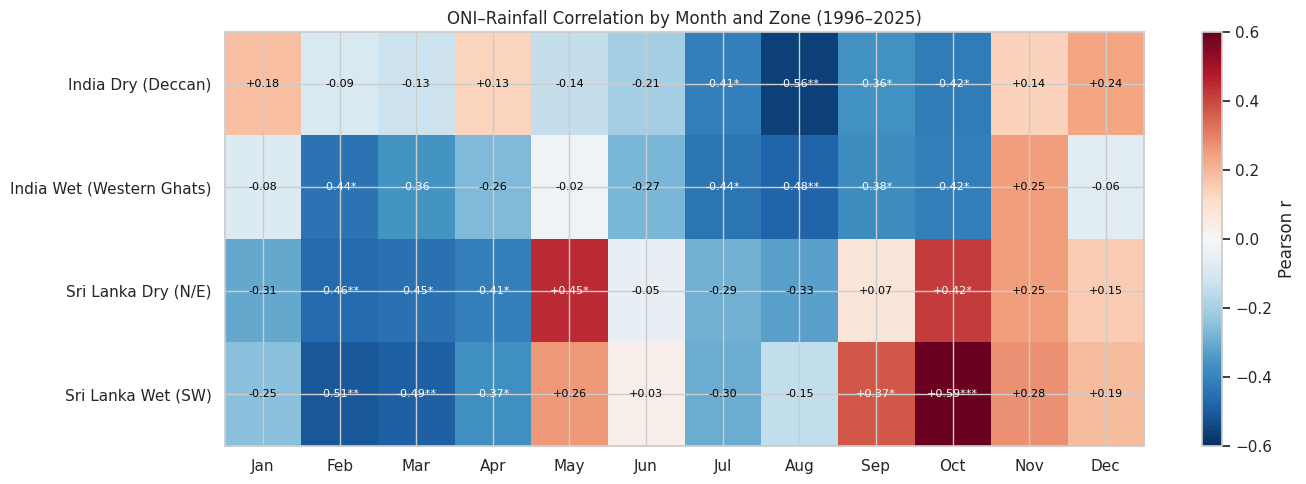

In [ ]:
pivot = monthly_df.pivot(index='zone', columns='month_name', values='r')
pivot_p = monthly_df.pivot(index='zone', columns='month_name', values='p')

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
pivot = pivot[month_order]
pivot_p = pivot_p[month_order]

fig, ax = plt.subplots(figsize=(14,5))
im = ax.imshow(pivot.values, cmap='RdBu_r', vmin=-0.6, vmax=0.6, aspect='auto')

for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        r_val = pivot.values[i,j]
        p_val = pivot_p.values[i,j]
        stars = '***' if p_val<0.001 else '**' if p_val<0.01 else '*' if p_val<0.05 else ''
        ax.text(j, i, f"{r_val:+.2f}{stars}", ha='center', va='center', fontsize=8,
                color='white' if abs(r_val)>0.35 else 'black')

ax.set_xticks(range(12)); ax.set_xticklabels(month_order)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
ax.set_title("ONI–Rainfall Correlation by Month and Zone (1996–2025)")
plt.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()

plt.savefig("monthly_sensitivity_heatmap.png", dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
from google.colab import files
files.download('monthly_sensitivity_heatmap.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def fit_month_regression(precip_da, label, month):
    monthly = precip_da.mean(dim=['latitude','longitude']).resample(time='MS').mean()
    df_ = monthly.to_dataframe(name='val').reset_index()
    df_.rename(columns={df_.columns[0]:'date'}, inplace=True)
    df_['m'] = df_['date'].dt.month
    df_['clim'] = df_.groupby('m')['val'].transform('mean')
    df_['anom'] = df_['val'] - df_['clim']
    merged = pd.merge(df_[['date','anom']], df_sorted[['date','ONI']], on='date', how='inner')
    sub = merged[merged['date'].dt.month == month]
    slope, intercept, r, p, se = linregress(sub['ONI'], sub['anom'])
    return {'zone': label, 'month': month, 'slope': slope, 'intercept': intercept, 'r': r, 'p': p}

key_windows = []
for month in [8, 9, 10]:  # India's key months
    key_windows.append(fit_month_regression(india_wet_precip, 'India Wet', month))
    key_windows.append(fit_month_regression(india_dry_precip, 'India Dry', month))
for month in [10]:  # Sri Lanka's wet signal
    key_windows.append(fit_month_regression(srilanka_wet_precip, 'Sri Lanka Wet', month))
    key_windows.append(fit_month_regression(srilanka_dry_precip, 'Sri Lanka Dry', month))
for month in [2, 3, 4]:  # Sri Lanka's dry signal
    key_windows.append(fit_month_regression(srilanka_wet_precip, 'Sri Lanka Wet', month))
    key_windows.append(fit_month_regression(srilanka_dry_precip, 'Sri Lanka Dry', month))

regressions_df = pd.DataFrame(key_windows)
print(regressions_df)

             zone  month     slope  intercept         r         p
0       India Wet      8 -1.309442  -0.009166 -0.479210  0.007377
1       India Dry      8 -1.539725  -0.010778 -0.562096  0.001226
2       India Wet      9 -0.803529  -0.013392 -0.377103  0.039951
3       India Dry      9 -0.767641  -0.012794 -0.361028  0.049986
4       India Wet     10 -0.617803  -0.011120 -0.415066  0.022560
5       India Dry     10 -0.606162  -0.010911 -0.419644  0.020969
6   Sri Lanka Wet     10  3.453259   0.062158  0.594174  0.000536
7   Sri Lanka Dry     10  1.295891   0.023326  0.421344  0.020402
8   Sri Lanka Wet      2 -1.282571  -0.053868 -0.507154  0.004231
9   Sri Lanka Dry      2 -1.230035  -0.051662 -0.464929  0.009635
10  Sri Lanka Wet      3 -2.611686  -0.067033 -0.489767  0.006012
11  Sri Lanka Dry      3 -1.505921  -0.038652 -0.446145  0.013467
12  Sri Lanka Wet      4 -2.562608  -0.037586 -0.367705  0.045599
13  Sri Lanka Dry      4 -1.412884  -0.020723 -0.409161  0.024759


In [ ]:
# 2026: NOAA's actual forecast values
# 2027: historical analog, average of 1997-98 and 2015-16 events at equivalent lead time
oni_scenario = {
    (2026, 8): 2.7,   # NOAA forecast
    (2026, 9): 3.1,   # NOAA forecast
    (2026, 10): 3.4,  # NOAA forecast
}

# Pull actual historical ONI for NDJ->FMA following the 1997-98 and 2015-16 peaks, as analog for Nov26-Apr27
analog_1997 = df_sorted[(df_sorted['date'] >= '1997-11-01') & (df_sorted['date'] <= '1998-04-01')][['date','ONI']].reset_index(drop=True)
analog_2015 = df_sorted[(df_sorted['date'] >= '2015-11-01') & (df_sorted['date'] <= '2016-04-01')][['date','ONI']].reset_index(drop=True)

analog_avg = pd.DataFrame({
    'month_offset': range(6),
    'oni_1997': analog_1997['ONI'].values,
    'oni_2015': analog_2015['ONI'].values,
})
analog_avg['oni_analog_mean'] = analog_avg[['oni_1997','oni_2015']].mean(axis=1)
print(analog_avg)

   month_offset  oni_1997  oni_2015  oni_analog_mean
0             0      2.34      2.45            2.395
1             1      2.37      2.59            2.480
2             2      2.22      2.50            2.360
3             3      1.91      2.21            2.060
4             4      1.40      1.69            1.545
5             5      1.03      1.11            1.070


In [ ]:
print("=== INDIA: remaining 2026 monsoon tail ===")
for month, oni_val in [(8, 2.7), (9, 3.1), (10, 3.4)]:
    for zone in ['India Wet', 'India Dry']:
        row = regressions_df[(regressions_df['zone']==zone) & (regressions_df['month']==month)].iloc[0]
        pred = row['slope'] * oni_val + row['intercept']
        sig = "significant" if row['p'] < 0.05 else "not significant"
        print(f"{zone}, month {month}, ONI={oni_val}: predicted anomaly = {pred:+.2f} mm/day (historical fit {sig}, p={row['p']:.3f})")

print("\n=== SRI LANKA: October 2026 (wet signal) ===")
oct_oni = 3.4
for zone in ['Sri Lanka Wet', 'Sri Lanka Dry']:
    row = regressions_df[(regressions_df['zone']==zone) & (regressions_df['month']==10)].iloc[0]
    pred = row['slope'] * oct_oni + row['intercept']
    sig = "significant" if row['p'] < 0.05 else "not significant"
    print(f"{zone}, October, ONI={oct_oni}: predicted anomaly = {pred:+.2f} mm/day (historical fit {sig}, p={row['p']:.3f})")

print("\n=== SRI LANKA: Feb-Apr 2027 (dry signal), using historical-analog ONI ===")
analog_oni_by_month = {2: analog_avg.loc[3,'oni_analog_mean'], 3: analog_avg.loc[4,'oni_analog_mean'], 4: analog_avg.loc[5,'oni_analog_mean']}
for month, oni_val in analog_oni_by_month.items():
    for zone in ['Sri Lanka Wet', 'Sri Lanka Dry']:
        row = regressions_df[(regressions_df['zone']==zone) & (regressions_df['month']==month)].iloc[0]
        pred = row['slope'] * oni_val + row['intercept']
        sig = "significant" if row['p'] < 0.05 else "not significant"
        print(f"{zone}, month {month}, analog ONI={oni_val:.2f}: predicted anomaly = {pred:+.2f} mm/day (historical fit {sig}, p={row['p']:.3f})")

=== INDIA: remaining 2026 monsoon tail ===
India Wet, month 8, ONI=2.7: predicted anomaly = -3.54 mm/day (historical fit significant, p=0.007)
India Dry, month 8, ONI=2.7: predicted anomaly = -4.17 mm/day (historical fit significant, p=0.001)
India Wet, month 9, ONI=3.1: predicted anomaly = -2.50 mm/day (historical fit significant, p=0.040)
India Dry, month 9, ONI=3.1: predicted anomaly = -2.39 mm/day (historical fit significant, p=0.050)
India Wet, month 10, ONI=3.4: predicted anomaly = -2.11 mm/day (historical fit significant, p=0.023)
India Dry, month 10, ONI=3.4: predicted anomaly = -2.07 mm/day (historical fit significant, p=0.021)

=== SRI LANKA: October 2026 (wet signal) ===
Sri Lanka Wet, October, ONI=3.4: predicted anomaly = +11.80 mm/day (historical fit significant, p=0.001)
Sri Lanka Dry, October, ONI=3.4: predicted anomaly = +4.43 mm/day (historical fit significant, p=0.020)

=== SRI LANKA: Feb-Apr 2027 (dry signal), using historical-analog ONI ===
Sri Lanka Wet, month 2, a

In [ ]:
# What's the actual observed ONI range in your October regression sample?
oct_sample = df_sorted[df_sorted['date'].dt.month==10]
print(f"Observed October ONI range in the 1996-2025 sample: {oct_sample['ONI'].min():.2f} to {oct_sample['ONI'].max():.2f}")

Observed October ONI range in the 1996-2025 sample: -1.54 to 2.28


In [ ]:
# Capped, more defensible prediction: use the max historically-observed October ONI instead of the forecast 3.4
capped_oni = oct_sample['ONI'].max()
row_wet = regressions_df[(regressions_df['zone']=='Sri Lanka Wet') & (regressions_df['month']==10)].iloc[0]
row_dry = regressions_df[(regressions_df['zone']=='Sri Lanka Dry') & (regressions_df['month']==10)].iloc[0]

pred_wet_capped = row_wet['slope'] * capped_oni + row_wet['intercept']
pred_dry_capped = row_dry['slope'] * capped_oni + row_dry['intercept']
print(f"Capped at observed max ONI ({capped_oni:.2f}): Wet zone {pred_wet_capped:+.2f} mm/day, Dry zone {pred_dry_capped:+.2f} mm/day")

Capped at observed max ONI (2.28): Wet zone +7.94 mm/day, Dry zone +2.98 mm/day
